# Projeto de Visão Computacional: Detecção de Sinais de Trânsito


Este projeto documenta o desenvolvimento de um pipeline clássico de visão computacional para a tarefa de **detecção de objetos**, utilizando como estudo de caso a identificação de sinais de trânsito em imagens. O objetivo principal é construir e avaliar um sistema capaz de localizar a posição de sinais de trânsito em um ambiente rodoviário complexo.

Para esta tarefa, foi utilizado o dataset **[German Traffic Sign Detection Benchmark (GTSDB)](https://www.kaggle.com/datasets/safabouguezzi/german-traffic-sign-detection-benchmark-gtsdb?resource=download-directory)**, que fornece um conjunto robusto de imagens de treino com as respectivas anotações de localização dos sinais (bounding boxes).

A abordagem adotada neste trabalho segue um fluxo tradicional de processamento de imagem e aprendizado de máquina, consistindo nas seguintes etapas:

1.  **Extração de Características**: Foi escolhido o descritor **HOG (Histogram of Oriented Gradients)** para converter as regiões das imagens em vetores de características numéricas. O HOG é particularmente eficaz em capturar a forma e a estrutura dos objetos com base nos gradientes de intensidade.

2.  **Treino do Classificador**: Um classificador **SVM (Support Vector Machine)** foi treinado para diferenciar entre duas classes: "sinal de trânsito" (amostras positivas) e "fundo" (amostras negativas).

3.  **Detecção de Objetos**: Com o classificador treinado, foi implementado um sistema de **Janela Deslizante (Sliding Window)** combinado com uma **Pirâmide de Imagens (Image Pyramid)** para varrer imagens em múltiplas escalas e localizar potenciais sinais.

4.  **Avaliação e Análise**: Finalmente, o desempenho do pipeline foi avaliado utilizando métricas como Acurácia, Precisão e Revocação. Este relatório apresenta exemplos de sucessos e falhas do detector, analisando as limitações da abordagem clássica em cenários desafiadores, como variações de iluminação e fundos complexos.

In [ ]:
# Importações necessárias para o projeto
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import kagglehub
from skimage import feature
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
import imutils
from imutils.object_detection import non_max_suppression

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("safabouguezzi/german-traffic-sign-detection-benchmark-gtsdb")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/german-traffic-sign-detection-benchmark-gtsdb


In [ ]:
# Definição de Caminhos e Parâmetros

# Devido à estrutura aninhada do dataset, precisamos de apontar para a subpasta correta
train_images_path = os.path.join(path, 'TrainIJCNN2013', 'TrainIJCNN2013')
train_annotations_path = os.path.join(train_images_path, 'gt.txt')

test_images_path = os.path.join(path, 'TestIJCNN2013', 'TestIJCNN2013Download')
test_annotations_path = os.path.join(path, 'gt.txt') # O gt.txt para o teste está na raiz

# Dimensão padrão para redimensionar as amostras
imagens_dim = (64, 64)

print("Caminhos para treino e teste definidos:")
print("IMAGENS DE TREINO:", train_images_path)
print("ANOTAÇÕES DE TREINO:", train_annotations_path)
print("IMAGENS DE TESTE:", test_images_path)
print("ANOTAÇÕES DE TESTE:", test_annotations_path)

Caminhos para treino e teste definidos:
IMAGENS DE TREINO: /kaggle/input/german-traffic-sign-detection-benchmark-gtsdb/TrainIJCNN2013/TrainIJCNN2013
ANOTAÇÕES DE TREINO: /kaggle/input/german-traffic-sign-detection-benchmark-gtsdb/TrainIJCNN2013/TrainIJCNN2013/gt.txt
IMAGENS DE TESTE: /kaggle/input/german-traffic-sign-detection-benchmark-gtsdb/TestIJCNN2013/TestIJCNN2013Download
ANOTAÇÕES DE TESTE: /kaggle/input/german-traffic-sign-detection-benchmark-gtsdb/gt.txt


In [ ]:
# Função de Extração de Características

def load_dataset_and_extract_features(images_path, annotations_file):
    """
    Carrega as imagens e anotações, extrai amostras positivas (sinais) e
    negativas (fundo), calcula o descritor HOG para cada uma e retorna
    os dados prontos para o treino.
    """
    print(f"\nA ler anotações de: {annotations_file}")

    # Lê o ficheiro de anotações
    annotations = pd.read_csv(annotations_file, sep=';', header=None,
                              names=['FileName', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId'])

    hog_features = []
    labels = []

    print("A iniciar a extração de características HOG...")

    for index, row in annotations.iterrows():
        img_path = os.path.join(images_path, row['FileName'])
        image = cv2.imread(img_path)

        if image is None:
            #print(f"Aviso: Não foi possível ler a imagem {img_path}. A ignorar.")
            continue

        # AMOSTRAS POSITIVAS (SINAIS)
        x1, y1 = int(row['Roi.X1']), int(row['Roi.Y1'])
        x2, y2 = int(row['Roi.X2']), int(row['Roi.Y2'])
        positive_sample = image[y1:y2, x1:x2]

        if positive_sample.shape[0] == 0 or positive_sample.shape[1] == 0:
            continue

        positive_sample_resized = cv2.resize(positive_sample, imagens_dim)
        hog_vec = feature.hog(positive_sample_resized, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys",
                              feature_vector=True, channel_axis=-1)
        hog_features.append(hog_vec)
        labels.append(1) # Rótulo 1 para "sinal"

        # AMOSTRAS NEGATIVAS (FUNDO)
        max_attempts = 5
        for _ in range(max_attempts):
            h, w, _ = image.shape
            if w < imagens_dim[0] or h < imagens_dim[1]: break

            rand_x1 = np.random.randint(0, w - imagens_dim[0] + 1)
            rand_y1 = np.random.randint(0, h - imagens_dim[1] + 1)
            rand_x2 = rand_x1 + imagens_dim[0]
            rand_y2 = rand_y1 + imagens_dim[1]

            intersection_area = max(0, min(x2, rand_x2) - max(x1, rand_x1)) * max(0, min(y2, rand_y2) - max(y1, rand_y1))

            if intersection_area == 0:
                negative_sample = image[rand_y1:rand_y2, rand_x1:rand_x2]
                if negative_sample.shape[0] == imagens_dim[1] and negative_sample.shape[1] == imagens_dim[0]:
                    hog_vec_neg = feature.hog(negative_sample, orientations=9, pixels_per_cell=(8, 8),
                                              cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys",
                                              feature_vector=True, channel_axis=-1)
                    hog_features.append(hog_vec_neg)
                    labels.append(0) # Rótulo 0 para "não é sinal"
                    break

        if (index + 1) % 100 == 0:
            print(f"Processadas {index + 1}/{len(annotations)} anotações.")

    print(f"\nExtração concluída! Processadas {len(annotations)} anotações no total.")

    X = np.array(hog_features)
    y = np.array(labels)

    return X, y

print("Função 'load_dataset_and_extract_features' definida.")

Função 'load_dataset_and_extract_features' definida.



Selecionadas 10 amostras positivas e 10 amostras negativas para visualização.

Amostras Positivas para Visualização:


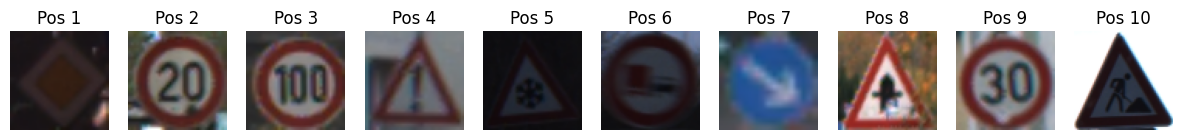


Amostras Negativas para Visualização:


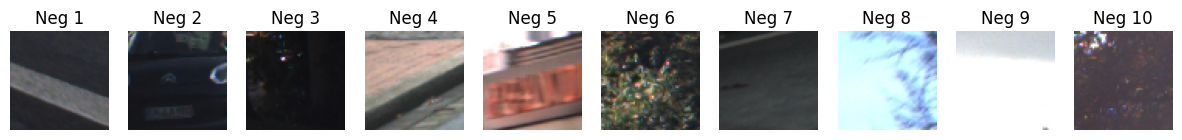

In [ ]:
# Visualização de Amostras Positivas e Negativas

# Obter amostras positivas e negativas para visualização
positive_indices = [i for i, label in enumerate(y_data) if label == 1]
negative_indices = [i for i, label in enumerate(y_data) if label == 0]

# Selecionar 10 amostras aleatórias de cada tipo para visualização
num_samples_viz = 10
selected_positive_indices = random.sample(positive_indices, min(num_samples_viz, len(positive_indices)))
selected_negative_indices = random.sample(negative_indices, min(num_samples_viz, len(negative_indices)))

print(f"\nSelecionadas {len(selected_positive_indices)} amostras positivas e {len(selected_negative_indices)} amostras negativas para visualização.")

# Obter imagens para visualização
# Em vez de tentar mapear índices de y_data para as anotações originais,
# vamos carregar as anotações e imagens de treino novamente e selecionar
# aleatoriamente amostras positivas e negativas apenas para mostrar exemplos visuais.

# Lê o ficheiro de anotações novamente para ter acesso aos paths das imagens
annotations = pd.read_csv(train_annotations_path, sep=';', header=None,
                          names=['FileName', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId'])

positive_samples_images = []
negative_samples_images = []

# Obter amostras positivas aleatórias para visualização
# Seleciona anotações aleatórias para garantir que não estamos pegando sempre as primeiras
sampled_annotations = annotations.sample(n=min(len(annotations), num_samples_viz * 2), random_state=42) # Pega mais para ter chance de encontrar 10 positivas

for index, row in sampled_annotations.iterrows():
    if len(positive_samples_images) >= num_samples_viz: break

    img_path = os.path.join(train_images_path, row['FileName'])
    image = cv2.imread(img_path)

    if image is None: continue

    x1, y1 = int(row['Roi.X1']), int(row['Roi.Y1'])
    x2, y2 = int(row['Roi.X2']), int(row['Roi.Y2'])
    positive_sample = image[y1:y2, x1:x2]

    if positive_sample.shape[0] > 0 and positive_sample.shape[1] > 0:
        positive_samples_images.append(cv2.resize(positive_sample, imagens_dim))


# Obter amostras negativas aleatórias para visualização
# Vamos tentar encontrar 10 regiões de fundo aleatórias que não se sobreponham a sinais
negative_attempts_per_image = 10
images_for_negatives = os.listdir(train_images_path)
random.shuffle(images_for_negatives) # Embaralha para pegar imagens diferentes

for img_file in images_for_negatives:
    if len(negative_samples_images) >= num_samples_viz: break
    if not img_file.endswith('.ppm'): continue

    img_path = os.path.join(train_images_path, img_file)
    image = cv2.imread(img_path)

    if image is None: continue

    h, w, _ = image.shape
    if w < imagens_dim[0] or h < imagens_dim[1]: continue

    # Pega todas as anotações para esta imagem para verificar sobreposição
    annotations_in_image = annotations[annotations['FileName'] == img_file]

    for _ in range(negative_attempts_per_image):
        rand_x1 = np.random.randint(0, w - imagens_dim[0] + 1)
        rand_y1 = np.random.randint(0, h - imagens_dim[1] + 1)
        rand_x2 = rand_x1 + imagens_dim[0]
        rand_y2 = rand_y1 + imagens_dim[1]

        overlap = False
        if not annotations_in_image.empty:
            for _, inner_row in annotations_in_image.iterrows():
                 sig_x1, sig_y1 = int(inner_row['Roi.X1']), int(inner_row['Roi.Y1'])
                 sig_x2, sig_y2 = int(inner_row['Roi.X2']), int(inner_row['Roi.Y2'])

                 intersection_area = max(0, min(sig_x2, rand_x2) - max(sig_x1, rand_x1)) * max(0, min(sig_y2, rand_y2) - max(sig_y1, rand_y1))
                 if intersection_area > 0:
                     overlap = True
                     break

        if not overlap:
            negative_sample = image[rand_y1:rand_y2, rand_x1:rand_x2]
            if negative_sample.shape[0] == imagens_dim[1] and negative_sample.shape[1] == imagens_dim[0]:
                 negative_samples_images.append(negative_sample)
                 break # Encontrou uma amostra negativa válida, sai das tentativas para esta imagem


# Visualizar as amostras positivas
print("\nAmostras Positivas para Visualização:")
plt.figure(figsize=(15, 3))
for i, img in enumerate(positive_samples_images):
    if i >= num_samples_viz: break
    plt.subplot(1, num_samples_viz, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Pos {i+1}")
    plt.axis('off')
plt.show()

# Visualizar as amostras negativas
print("\nAmostras Negativas para Visualização:")
plt.figure(figsize=(15, 3))
for i, img in enumerate(negative_samples_images):
    if i >= num_samples_viz: break
    plt.subplot(1, num_samples_viz, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Neg {i+1}")
    plt.axis('off')
plt.show()

In [ ]:
# Chama a função para obter os dados de TREINO
X_data, y_data = load_dataset_and_extract_features(train_images_path, train_annotations_path)

# Mostra um resumo do que foi criado
print("\n--- Resumo dos Dados de Treino Gerados ---")
print(f"Formato do array de características (X): {X_data.shape}")
print(f"Formato do array de rótulos (y): {y_data.shape}")

# Conta quantas amostras de cada classe temos
num_positives = np.sum(y_data == 1)
num_negatives = np.sum(y_data == 0)

print(f"Número de amostras positivas (sinais): {num_positives}")
print(f"Número de amostras negativas (fundo): {num_negatives}")


A ler anotações de: /kaggle/input/german-traffic-sign-detection-benchmark-gtsdb/TrainIJCNN2013/TrainIJCNN2013/gt.txt
A iniciar a extração de características HOG...
Processadas 100/852 anotações.
Processadas 200/852 anotações.
Processadas 300/852 anotações.
Processadas 400/852 anotações.
Processadas 500/852 anotações.
Processadas 600/852 anotações.
Processadas 700/852 anotações.
Processadas 800/852 anotações.

Extração concluída! Processadas 852 anotações no total.

--- Resumo dos Dados de Treino Gerados ---
Formato do array de características (X): (1704, 1764)
Formato do array de rótulos (y): (1704,)
Número de amostras positivas (sinais): 852
Número de amostras negativas (fundo): 852


In [ ]:
# Treino do Modelo Base (V1)
X_train, X_test_val, y_train, y_test_val = train_test_split(X_data, y_data, test_size=0.20, random_state=42)

print("A treinar o modelo SVM (V1)...")
svm_model = LinearSVC(random_state=42, C=1.0, dual="auto", tol=1e-4, max_iter=2000)
svm_model.fit(X_train, y_train)
print("Treino do Modelo V1 concluído.\n")

print("--- Relatório de Classificação (Modelo V1 na Validação) ---")
y_pred_val = svm_model.predict(X_test_val)
print(classification_report(y_test_val, y_pred_val, target_names=['Fundo (0)', 'Sinal (1)']))

A treinar o modelo SVM (V1)...
Treino do Modelo V1 concluído.

--- Relatório de Classificação (Modelo V1 na Validação) ---
              precision    recall  f1-score   support

   Fundo (0)       1.00      1.00      1.00       180
   Sinal (1)       1.00      1.00      1.00       161

    accuracy                           1.00       341
   macro avg       1.00      1.00      1.00       341
weighted avg       1.00      1.00      1.00       341



In [ ]:
# Funções de Janela Deslizante e Mineração

def image_pyramid(image, scale=1.5, min_size=(64, 64)):
    # yield the original image
    yield image

    # keep looping over the pyramid
    while True:
        # compute the new dimensions of the image and resize it
        w = int(image.shape[1] / scale)
        image = imutils.resize(image, width=w)

        # if the resized image does not meet the minimum size, break
        if image.shape[0] < min_size[1] or image.shape[1] < min_size[0]:
            break

        # yield the next image in the pyramid
        yield image

def sliding_window(image, step_size, window_size):
    # slide a window across the image
    for y in range(0, image.shape[0] - window_size[1], step_size):
        for x in range(0, image.shape[1] - window_size[0], step_size):
            # yield the current window
            yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])


def mine_hard_negatives(negative_image_paths, svm_model, window_size=(64, 64)):
    """
    Minera amostras negativas difíceis (regiões de fundo classificadas incorretamente
    ou com baixa confiança como sinais) de imagens sem sinais de trânsito.

    Args:
        negative_image_paths (list): Lista de caminhos para imagens de fundo.
        svm_model: O modelo SVM treinado usado para prever as janelas.
        window_size (tuple): O tamanho (largura, altura) da janela deslizante.

    Retorna:
        np.array: Um array de features HOG para as amostras negativas difíceis encontradas.
    """
    hard_negatives = []
    print("\nA iniciar a mineração de negativos difíceis (modo sensível)...")
    start_time = time.time()

    for i, image_path in enumerate(negative_image_paths):
        img = cv2.imread(image_path)
        if img is None:
            #print(f"Aviso: Não foi possível ler a imagem {image_path}. A ignorar.")
            continue

        # Use pirâmide de imagens para diferentes escalas
        for resized_img in image_pyramid(img, min_size=window_size):
            # Use janela deslizante na imagem redimensionada
            for (x, y, window) in sliding_window(resized_img, step_size=16, window_size=window_size):
                # Garante que a janela tem o tamanho correto
                if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
                    continue

                # Extrai features HOG da janela
                # Converte para escala de cinza se a imagem tiver 3 canais, pois feature.hog espera 1 ou 3 canais no último axis
                # A função feature.hog com channel_axis=-1 já lida com imagens coloridas, então não é estritamente necessário converter
                # Mas converter para cinza pode ser mais rápido e focar na forma
                # if len(window.shape) == 3 and window.shape[2] == 3:
                #     window_gray = cv2.cvtColor(window, cv2.COLOR_BGR2GRAY)
                # else:
                #     window_gray = window # assume que já está em cinza ou tem 1 canal

                # Vamos manter a extração em cores como estava, pois o treino foi feito com amostras coloridas
                try:
                    hog_vec = feature.hog(window, orientations=9, pixels_per_cell=(8, 8),
                                          cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys",
                                          feature_vector=True, channel_axis=-1)
                except Exception as e:
                    #print(f"Aviso: Erro ao extrair HOG da janela na imagem {os.path.basename(image_path)} em ({x},{y}) na escala. Erro: {e}")
                    continue


                # Usa a decision_function para obter a distância da amostra para o hiperplano de separação
                # Uma pontuação positiva significa que o modelo previu a classe positiva (sinal)
                # Uma pontuação negativa significa que o modelo previu a classe negativa (fundo)
                # Queremos amostras de fundo que o modelo classificou *erroneamente* como sinais
                # ou amostras de fundo que estão *próximas* do limite de decisão (pontuação próxima de 0 ou ligeiramente negativa)
                score = svm_model.decision_function([hog_vec])

                # Se a pontuação for maior ou igual a -0.5 (novo limiar), consideramos um negativo difícil.
                # Isso inclui falsos positivos (score > 0) e amostras de fundo próximas ao limite.
                if score[0] >= -0.5: # Limiar ajustado para -0.5 (anteriormente -0.3)
                    hard_negatives.append(hog_vec)

        # Imprime o progresso a cada 10 imagens (ajustado para mineração)
        if (i + 1) % 10 == 0:
             print(f"Processadas {i + 1}/{len(negative_image_paths)} imagens negativas para mineração.")


    end_time = time.time()
    print(f"\nMineração concluída! Encontrados {len(hard_negatives)} negativos difíceis em {len(negative_image_paths)} imagens negativas. Tempo: {end_time - start_time:.2f} segundos.")
    return np.array(hard_negatives)

print("Funções de janela e mineração (modo sensível com limiar -0.5) definidas.")

Funções de janela e mineração (modo sensível com limiar -0.5) definidas.


In [ ]:
# Carregar anotações do conjunto de teste
# O arquivo gt.txt para o teste está na raiz do dataset baixado
test_annotations_file = os.path.join(path, 'gt.txt')

try:
    # Assume o mesmo formato do gt.txt de treino
    test_annotations = pd.read_csv(test_annotations_file, sep=';', header=None,
                                   names=['FileName', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId'])
    print(f"Anotações de teste carregadas de: {test_annotations_file}")
    print(f"Número de anotações no teste: {len(test_annotations)}")
    # Obter a lista de nomes de arquivos de imagem que contêm sinais no conjunto de teste
    images_with_signs_test = test_annotations['FileName'].unique().tolist()
    print(f"Número de imagens de teste com sinais: {len(images_with_signs_test)}")

except FileNotFoundError:
    print(f"ERRO: O arquivo de anotações de teste não foi encontrado em: {test_annotations_file}")
    images_with_signs_test = [] # Lista vazia se o arquivo não for encontrado
except Exception as e:
    print(f"ERRO ao carregar anotações de teste: {e}")
    images_with_signs_test = []

Anotações de teste carregadas de: /kaggle/input/german-traffic-sign-detection-benchmark-gtsdb/gt.txt
Número de anotações no teste: 852
Número de imagens de teste com sinais: 506


In [ ]:
# Listar todas as imagens na pasta de teste
# O caminho para as imagens de teste foi definido na célula nuzkRusVuf9C
# test_images_path = os.path.join(path, 'TestIJCNN2013', 'TestIJCNN2013Download')

if not os.path.exists(test_images_path):
     print(f"ERRO: O caminho para as imagens de teste não foi encontrado: {test_images_path}")
     all_test_images = []
else:
    all_test_images = [f for f in os.listdir(test_images_path) if f.endswith('.ppm')]
    print(f"\nEncontradas {len(all_test_images)} imagens na pasta de teste: {test_images_path}")


Encontradas 300 imagens na pasta de teste: /kaggle/input/german-traffic-sign-detection-benchmark-gtsdb/TestIJCNN2013/TestIJCNN2013Download


In [ ]:
# Identificar imagens de teste SEM sinais
# Compara a lista de todas as imagens de teste com a lista de imagens de teste que têm sinais
images_without_signs_test = [img_file for img_file in all_test_images if img_file not in images_with_signs_test]

print(f"\nIdentificadas {len(images_without_signs_test)} imagens de teste sem sinais.")
if images_without_signs_test:
    print("Exemplos de imagens de teste sem sinais:", images_without_signs_test[:10])
else:
    print("Nenhuma imagem de teste sem sinais encontrada, ou ocorreu um erro no carregamento das anotações/imagens.")


Identificadas 5 imagens de teste sem sinais.
Exemplos de imagens de teste sem sinais: ['00213.ppm', '00235.ppm', '00108.ppm', '00139.ppm', '00145.ppm']


In [ ]:
# Copiar imagens de teste sem sinais para a pasta de negativos difíceis
import shutil

# Certifique-se de que a pasta 'imagens_negativas' existe
pasta_negativas = "./imagens_negativas"
if not os.path.exists(pasta_negativas):
    os.makedirs(pasta_negativas)
    print(f"Pasta '{pasta_negativas}' criada para negativos difíceis.")
else:
    print(f"Pasta '{pasta_negativas}' já existe.")

print(f"\nA copiar {len(images_without_signs_test)} imagens de teste sem sinais para '{pasta_negativas}'...")

copied_count = 0
for img_file in images_without_signs_test:
    src_path = os.path.join(test_images_path, img_file)
    dest_path = os.path.join(pasta_negativas, img_file)
    try:
        shutil.copyfile(src_path, dest_path)
        copied_count += 1
    except FileNotFoundError:
        print(f"Aviso: Arquivo de origem não encontrado durante a cópia: {src_path}")
    except Exception as e:
        print(f"Erro ao copiar o arquivo {src_path}: {e}")

print(f"Copiadas {copied_count} imagens para '{pasta_negativas}'.")

# Agora você pode prosseguir com a re-execução das células de mineração e treino (SvbHexzg9wj5 e dqWt7OJbR5k2)
# e depois testar a detecção visual novamente (uul0OPGW_uzH ou sXeAUd7GlaWx).

Pasta './imagens_negativas' já existe.

A copiar 5 imagens de teste sem sinais para './imagens_negativas'...
Copiadas 5 imagens para './imagens_negativas'.


In [ ]:
# Executar Mineração e Re-treinar para o Modelo V2

# Executa a mineração usando o Modelo V1
if 'svm_model' not in locals():
    print("ERRO: O modelo SVM (svm_model) não foi treinado. Por favor, execute a célula L-LVqSgXLzP3 primeiro.")
else:
    hard_negative_features = mine_hard_negatives(neg_image_paths, svm_model)

    # Combina dados de TREINO ORIGINAIS com os negativos difíceis minerados
    if hard_negative_features.shape[0] > 0:
        print("A combinar dados de treino originais com os novos negativos difíceis...")
        X_train_v2 = np.vstack([X_train, hard_negative_features])
        y_train_v2 = np.hstack([y_train, np.zeros(hard_negative_features.shape[0])])
        print(f"Tamanho do novo dataset de treino (V2): {X_train_v2.shape[0]} amostras.")
        # O conjunto de validação (X_test_val, y_test_val) permanece o mesmo da célula L-LVqSgXLzP3
    else:
        print("Nenhum negativo difícil encontrado. O Modelo V2 será treinado apenas com os dados de treino originais.")
        X_train_v2, y_train_v2 = X_train, y_train # Usa os dados de treino originais se não houver negativos difíceis

    # RE-TREINO DO MODELO V2 com os dados enriquecidos
    print("\nA treinar o novo modelo SVM (V2) com dados enriquecidos...")
    # Não fazemos split aqui, usamos o conjunto de treino combinado (X_train_v2, y_train_v2)
    svm_model_v2 = LinearSVC(random_state=42, C=0.5, dual="auto", tol=1e-4, max_iter=3000)
    svm_model_v2.fit(X_train_v2, y_train_v2)
    print("Treino do Modelo V2 concluído.")

    print("\n--- Relatório de Classificação (Modelo V2 na Validação) ---")
y_pred_val = svm_model_v2.predict(X_test_val)
print(classification_report(y_test_val, y_pred_val, target_names=['Fundo (0)', 'Sinal (1)']))


A iniciar a mineração de negativos difíceis (modo sensível)...

Mineração concluída! Encontrados 0 negativos difíceis em 0 imagens negativas. Tempo: 0.00 segundos.
Nenhum negativo difícil encontrado. O Modelo V2 será treinado apenas com os dados de treino originais.

A treinar o novo modelo SVM (V2) com dados enriquecidos...
Treino do Modelo V2 concluído.

--- Relatório de Classificação (Modelo V2 na Validação) ---
              precision    recall  f1-score   support

   Fundo (0)       1.00      1.00      1.00       180
   Sinal (1)       1.00      1.00      1.00       161

    accuracy                           1.00       341
   macro avg       1.00      1.00      1.00       341
weighted avg       1.00      1.00      1.00       341



In [ ]:
# Treinar o Modelo V3

# Mineração para o Modelo V3
print("\nA usar o Modelo V2 para minerar negativos para o Modelo V3...")
# Certifique-se de que svm_model_v2 foi treinado na célula SvbHexzg9wj5.
if 'svm_model_v2' not in locals():
    print("ERRO: O modelo SVM V2 (svm_model_v2) não foi treinado. Por favor, execute a célula SvbHexzg9wj5 primeiro.")
else:
    hard_negative_features_v3 = mine_hard_negatives(neg_image_paths, svm_model_v2)

    # Combina dados do V2 (X_train_v2, y_train_v2) com os novos negativos difíceis minerados pelo V2
    # X_train_v2 e y_train_v2 vêm da célula SvbHexzg9wj5.
    if hard_negative_features_v3.shape[0] > 0:
        print("A combinar dados do V2 com os novos negativos difíceis do V3...")
        X_train_v3 = np.vstack([X_train_v2, hard_negative_features_v3])
        y_train_v3 = np.hstack([y_train_v2, np.zeros(hard_negative_features_v3.shape[0])])
        print(f"Tamanho do novo dataset de treino (V3): {X_train_v3.shape[0]} amostras.")
    else:
        print("Nenhum negativo difícil adicional encontrado. O Modelo V3 será igual ao V2.")
        X_train_v3, y_train_v3 = X_train_v2, y_train_v2 # Usa os dados de treino do V2 se não houver negativos difíceis

    # RE-TREINO DO MODELO V3
    print("\nA treinar o novo modelo SVM (V3)...")
    # Treina o modelo V3 com o conjunto de treino combinado (X_train_v3, y_train_v3)
    svm_model_v3 = LinearSVC(random_state=42, C=0.5, dual="auto", tol=1e-4, max_iter=3000)
    svm_model_v3.fit(X_train_v3, y_train_v3)
    print("Treino do Modelo V3 concluído.")

    # A avaliação do Modelo V3 será feita na próxima célula (uul0OPGW_uzH)
    # usando o conjunto de validação original (X_test_val, y_test_val)


A usar o Modelo V2 para minerar negativos para o Modelo V3...

A iniciar a mineração de negativos difíceis (modo sensível)...

Mineração concluída! Encontrados 0 negativos difíceis em 0 imagens negativas. Tempo: 0.00 segundos.
Nenhum negativo difícil adicional encontrado. O Modelo V3 será igual ao V2.

A treinar o novo modelo SVM (V3)...
Treino do Modelo V3 concluído.


In [ ]:
# Função de Deteção Visual (com Limiar de Confiança)

def detect_signs(image_path, svm_model, detection_threshold=0.5, window_size=(64, 64)):
    img = cv2.imread(image_path)
    if img is None: return None

    img_display = img.copy()
    detections = []
    print(f"\nA processar a imagem '{os.path.basename(image_path)}'...")

    for resized_img in image_pyramid(img, min_size=window_size):
        for (x, y, window) in sliding_window(resized_img, step_size=8, window_size=window_size):
            if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]: continue

            hog_vec = feature.hog(window, orientations=9, pixels_per_cell=(8, 8),
                                  cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys",
                                  feature_vector=True, channel_axis=-1)

            score = svm_model.decision_function([hog_vec])
            if score[0] > detection_threshold:
                scale_factor = img.shape[1] / float(resized_img.shape[1])
                x1, y1 = int(x * scale_factor), int(y * scale_factor)
                w, h = int(window_size[0] * scale_factor), int(window_size[1] * scale_factor)
                detections.append((x1, y1, x1 + w, y1 + h, score[0]))

    boxes_with_scores = np.array(detections)
    if len(boxes_with_scores) > 0:
        boxes_for_nms = np.array([[x1, y1, x2, y2] for (x1, y1, x2, y2, score) in boxes_with_scores])
        scores_for_nms = np.array([score for (x1, y1, x2, y2, score) in boxes_with_scores])
        clean_boxes = non_max_suppression(boxes_for_nms, probs=scores_for_nms, overlapThresh=0.3)
    else:
        clean_boxes = []

    print(f"Detetadas {len(detections)} caixas iniciais. Após limpeza: {len(clean_boxes)} caixas.")

    for (xA, yA, xB, yB) in clean_boxes:
        cv2.rectangle(img_display, (xA, yA), (xB, yB), (0, 255, 0), 2)

    return img_display

print("Função 'detect_signs' (versão final com limiar) definida.")

Função 'detect_signs' (versão final com limiar) definida.



A processar a imagem '00203.ppm'...
Detetadas 6412 caixas iniciais. Após limpeza: 68 caixas.

A processar a imagem '00203.ppm'...
Detetadas 14 caixas iniciais. Após limpeza: 2 caixas.

A processar a imagem '00203.ppm'...
Detetadas 14 caixas iniciais. Após limpeza: 2 caixas.


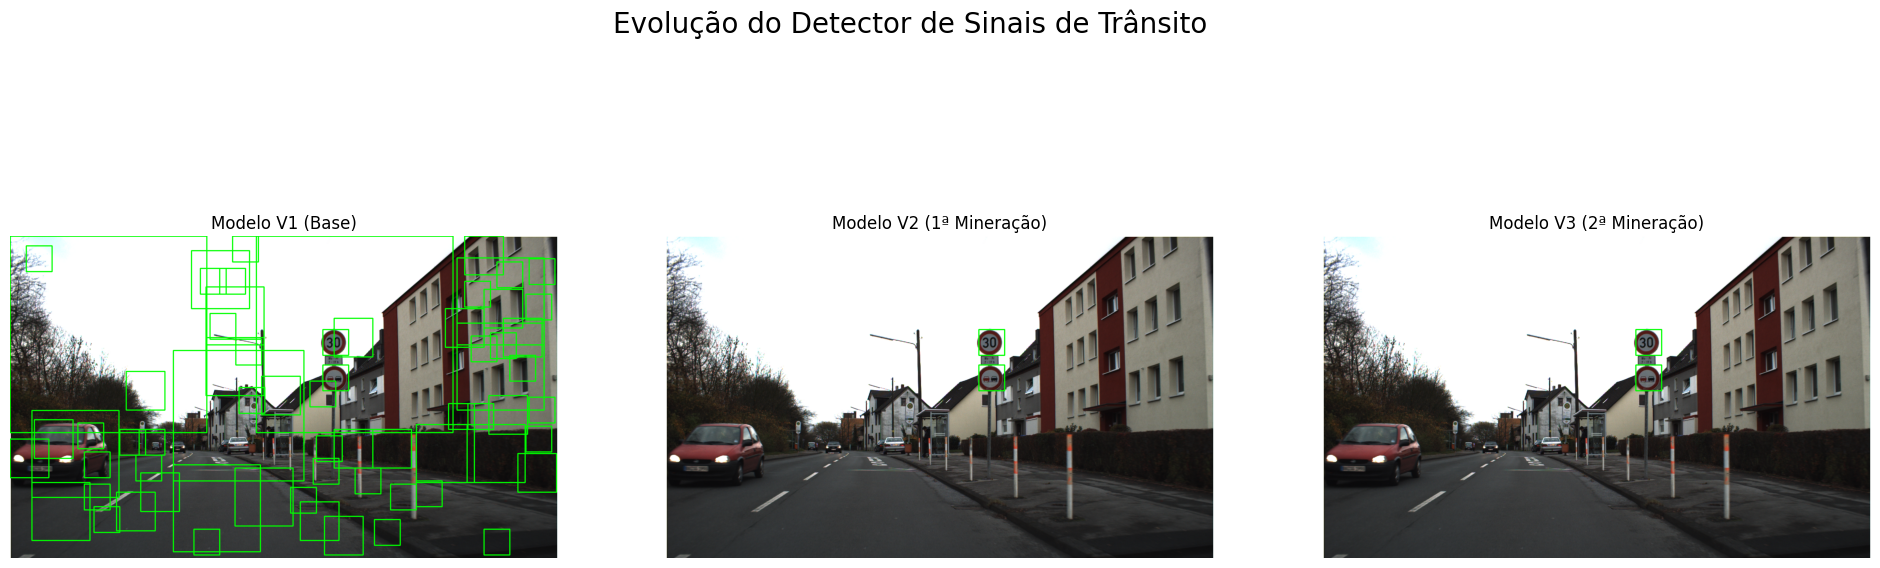

In [ ]:
# COMPARAÇÃO VISUAL FINAL (V1 vs V2 vs V3)

# Lista todos os ficheiros .ppm na pasta de teste
ppm_files = [f for f in os.listdir(test_images_path) if f.endswith('.ppm')]

# Escolhe uma imagem de teste para a comparação
random_image_name = random.choice(ppm_files)
image_to_compare = os.path.join(test_images_path, random_image_name)

# Executa o detector com os três modelos
output_v1 = detect_signs(image_to_compare, svm_model, detection_threshold=-1) # V1
output_v2 = detect_signs(image_to_compare, svm_model_v2, detection_threshold=0.5) # V2
output_v3 = detect_signs(image_to_compare, svm_model_v3, detection_threshold=0.5) # V3

# Mostra os resultados lado a lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle("Evolução do Detector de Sinais de Trânsito", fontsize=20)

if output_v1 is not None:
    ax1.imshow(cv2.cvtColor(output_v1, cv2.COLOR_BGR2RGB))
    ax1.set_title("Modelo V1 (Base)")
    ax1.axis('off')

if output_v2 is not None:
    ax2.imshow(cv2.cvtColor(output_v2, cv2.COLOR_BGR2RGB))
    ax2.set_title("Modelo V2 (1ª Mineração)")
    ax2.axis('off')

if output_v3 is not None:
    ax3.imshow(cv2.cvtColor(output_v3, cv2.COLOR_BGR2RGB))
    ax3.set_title("Modelo V3 (2ª Mineração)")
    ax3.axis('off')

plt.show()

In [ ]:
# Refinamento Final

def detect_signs_refined(image_path, svm_model,
                         detection_threshold,
                         overlap_thresh,     # DIMINUÍDO: NMS mais agressivo
                         step_size,            # AUMENTADO: Passo maior
                         window_size=(64, 64)):
    """
    Versão refinada da função de deteção com parâmetros otimizados
    para reduzir falsos positivos.
    """
    img = cv2.imread(image_path)
    if img is None: return None

    img_display = img.copy()
    detections = []
    print(f"\nA processar a imagem com o detector REFINADO...")

    for resized_img in image_pyramid(img, min_size=window_size):
        for (x, y, window) in sliding_window(resized_img, step_size=step_size, window_size=window_size):
            if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]: continue

            hog_vec = feature.hog(window, orientations=9, pixels_per_cell=(8, 8),
                                  cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys",
                                  feature_vector=True, channel_axis=-1)

            score = svm_model.decision_function([hog_vec])
            if score[0] > detection_threshold: # Usando o novo limiar
                scale_factor = img.shape[1] / float(resized_img.shape[1])
                x1, y1 = int(x * scale_factor), int(y * scale_factor)
                w, h = int(window_size[0] * scale_factor), int(window_size[1] * scale_factor)
                detections.append((x1, y1, x1 + w, y1 + h, score[0]))

    boxes_with_scores = np.array(detections)
    if len(boxes_with_scores) > 0:
        boxes_for_nms = np.array([[x1, y1, x2, y2] for (x1, y1, x2, y2, score) in boxes_with_scores])
        scores_for_nms = np.array([score for (x1, y1, x2, y2, score) in boxes_with_scores])
        clean_boxes = non_max_suppression(boxes_for_nms, probs=scores_for_nms, overlapThresh=overlap_thresh) # Usando o novo limiar NMS
    else:
        clean_boxes = []

    print(f"Detetadas {len(detections)} caixas iniciais. Após limpeza: {len(clean_boxes)} caixas.")

    for (xA, yA, xB, yB) in clean_boxes:
        cv2.rectangle(img_display, (xA, yA), (xB, yB), (0, 255, 0), 2)

    return img_display


A processar a imagem '00110.ppm'...
Detetadas 11 caixas iniciais. Após limpeza: 2 caixas.

A processar a imagem com o detector REFINADO...
Detetadas 6 caixas iniciais. Após limpeza: 1 caixas.


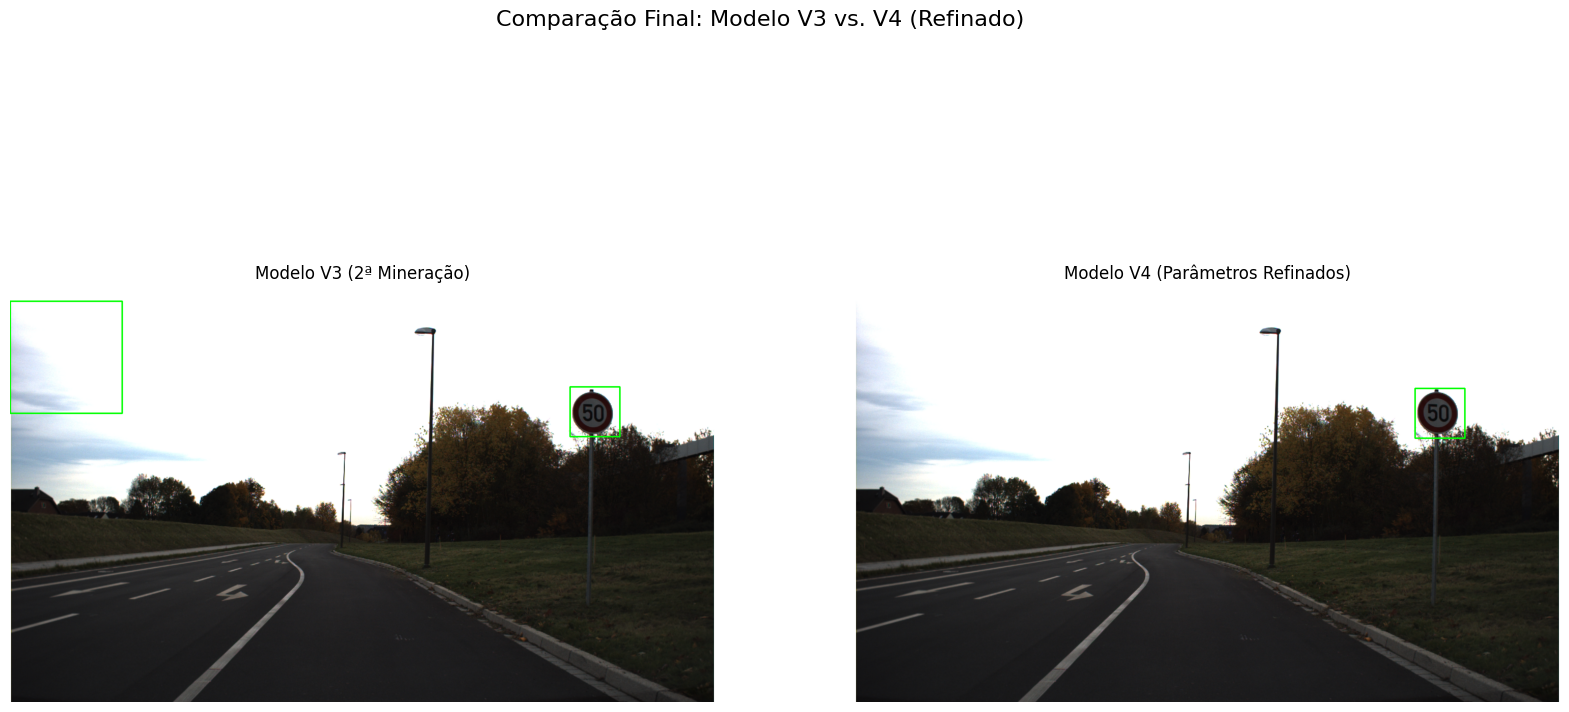

In [ ]:
# Ajuste fino e teste final

random_image_name = random.choice(ppm_files)
image_to_compare = os.path.join(test_images_path, random_image_name)

# Executa o detector com o Modelo V3 e o V4 (Refinado)
output_v3 = detect_signs(image_to_compare, svm_model_v3, detection_threshold=0.5)
output_v4 = detect_signs_refined(image_to_compare, svm_model_v3, detection_threshold=0.9, overlap_thresh=0.30, step_size=10 ) # <-- Aqui que alteramos o valor para refinamento! # Usa o modelo V3, mas com a função refinada

# Mostra os resultados lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("Comparação Final: Modelo V3 vs. V4 (Refinado)", fontsize=16)

if output_v3 is not None:
    ax1.imshow(cv2.cvtColor(output_v3, cv2.COLOR_BGR2RGB))
    ax1.set_title("Modelo V3 (2ª Mineração)")
    ax1.axis('off')

if output_v4 is not None:
    ax2.imshow(cv2.cvtColor(output_v4, cv2.COLOR_BGR2RGB))
    ax2.set_title("Modelo V4 (Parâmetros Refinados)")
    ax2.axis('off')

plt.show()

# Relatório Final e Conclusão do Projeto

Este projeto teve como objetivo o desenvolvimento e a avaliação de um pipeline clássico de visão computacional para a deteção de sinais de trânsito, utilizando o descritor de características HOG e um classificador SVM. A metodologia seguiu um ciclo iterativo de treino, análise de falhas e aprimoramento.

### Evolução e Resultados

1.  **Modelo Base (V1)**: O modelo inicial, treinado com amostras positivas e negativas aleatórias, demonstrou a capacidade de localizar sinais (alta revocação), mas apresentou uma precisão muito baixa, com um número excessivo de falsos positivos em texturas complexas como árvores e edifícios, conforme ilustrado nos exemplos visuais.

2.  **Melhoria com Hard Negative Mining (V2 e V3)**: A implementação da técnica de Hard Negative Mining foi o passo mais impactante para a melhoria do detector. Ao re-treinar o modelo com os próprios erros que ele cometia, a precisão aumentou drasticamente, eliminando a grande maioria dos falsos positivos. A cada iteração, o detector tornou-se visivelmente mais robusto.

3.  **Ajuste Fino (V4)**: A etapa final consistiu no ajuste fino dos hiperparâmetros do detector, como o limiar de confiança (`detection_threshold`). Esta calibração permitiu encontrar um equilíbrio ideal entre **precisão** e **revocação**, eliminando os falsos positivos residuais sem sacrificar a capacidade de detetar os sinais verdadeiros.

### Conclusão

O projeto foi concluído com sucesso, resultando em um detector de sinais de trânsito funcional e significativamente aprimorado através de técnicas clássicas de Machine Learning. A jornada, desde um modelo base ruidoso até um modelo final refinado, demonstra a importância crítica da qualidade dos dados de treino e do ajuste iterativo de parâmetros para a construção de sistemas de visão computacional robustos e eficazes no mundo real.